# 03 — TFT Forecaster
### Standard Temporal Fusion Transformer - Event-Based Breakdown Forecasting
> Run 00_Data_Preparation.ipynb first.
>
> **Model A:** Binary forecaster (breakdown coming within H=5 events? yes/no)
> **Model B:** Type forecaster (which breakdown type is coming?)


In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import f1_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {DEVICE}')


✅ Device: cpu


In [2]:
with open('prepared_forecasting.pkl','rb') as f: d = pickle.load(f)
with open('encoder_reason.pkl','rb') as f: encoder_reason = pickle.load(f)

X_train = torch.FloatTensor(d['X_fc_train_seq']).to(DEVICE)
X_test  = torch.FloatTensor(d['X_fc_test_seq']).to(DEVICE)
y_train_bin = torch.LongTensor(d['y_fc_train_bin_seq']).to(DEVICE)
y_test_bin  = torch.LongTensor(d['y_fc_test_bin_seq']).to(DEVICE)
y_train_type = torch.LongTensor(d['y_fc_train_type_seq']).to(DEVICE)
y_test_type  = torch.LongTensor(d['y_fc_test_type_seq']).to(DEVICE)

NUM_FEATURES      = d['num_features']
TIME_STEPS        = d['TIME_STEPS']
H                 = d['H']
NUM_REASON_CLASSES = d['num_reason_classes']

# CLASS WEIGHTS (binary)
cc_bin = np.bincount(d['y_fc_train_bin_seq'])
cw_bin = 1.0 / cc_bin
cw_bin = cw_bin / cw_bin.sum() * len(cw_bin)
weights_bin = torch.FloatTensor(cw_bin).to(DEVICE)

train_loader_bin = DataLoader(TensorDataset(X_train, y_train_bin), batch_size=32, shuffle=True)

print(f'✅ Data loaded.')
print(f'   Features: {NUM_FEATURES}, TIME_STEPS: {TIME_STEPS}, H: {H}')
print(f'   Binary class counts : {cc_bin}')
print(f'   Binary class weights: {cw_bin.round(3)}')
print(f'   Reason classes: {list(encoder_reason.classes_)}')


✅ Data loaded.
   Features: 67, TIME_STEPS: 5, H: 5
   Binary class counts : [771  24]
   Binary class weights: [0.06 1.94]
   Reason classes: ['High thread tension', 'No Breakdown', 'Sewing without thread']


---
## TFT Architecture


In [3]:
class GRN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout=0.1):
        super().__init__()
        self.fc1        = nn.Linear(input_size, hidden_size)
        self.fc2        = nn.Linear(hidden_size, output_size)
        self.gate_fc    = nn.Linear(hidden_size, output_size)
        self.elu        = nn.ELU()
        self.sigmoid    = nn.Sigmoid()
        self.dropout    = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(output_size)
        self.residual   = nn.Linear(input_size, output_size) if input_size != output_size else nn.Identity()

    def forward(self, x):
        h    = self.elu(self.fc1(x))
        h    = self.dropout(h)
        gate = self.sigmoid(self.gate_fc(h))
        out  = gate * self.fc2(h)
        return self.layer_norm(out + self.residual(x))


class VariableSelectionNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, dropout=0.1):
        super().__init__()
        self.input_grn = GRN(input_size, hidden_size, hidden_size, dropout)
        self.selection = nn.Linear(hidden_size, input_size)

    def forward(self, x):
        h = self.input_grn(x)
        weights = torch.softmax(self.selection(h), dim=-1)
        self.var_weights = weights.detach().cpu()
        return h * weights.unsqueeze(-1).sum(dim=-1).unsqueeze(-1).expand_as(h) if len(h.shape) > 2 else h


class TFT_Forecaster(nn.Module):
    def __init__(self, num_features, time_steps, num_classes,
                 hidden_size=64, num_heads=4, dropout=0.3):
        super().__init__()
        self.time_steps   = time_steps
        self.input_proj   = GRN(num_features, hidden_size, hidden_size, dropout)
        self.lstm_encoder = nn.LSTM(hidden_size, hidden_size, 2,
                                    batch_first=True, dropout=dropout)
        self.attention    = nn.MultiheadAttention(hidden_size, num_heads,
                                                   dropout=dropout, batch_first=True)
        self.attn_norm    = nn.LayerNorm(hidden_size)
        self.post_attn_grn = GRN(hidden_size, hidden_size, hidden_size, dropout)
        self.classifier   = nn.Sequential(
            nn.Linear(hidden_size, 32), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(32, num_classes)
        )

    def forward(self, x):
        proj_out = []
        for t in range(self.time_steps):
            proj_out.append(self.input_proj(x[:, t, :]))
        proj_seq = torch.stack(proj_out, dim=1)
        lstm_out, _ = self.lstm_encoder(proj_seq)
        attn_out, self.attn_weights = self.attention(lstm_out, lstm_out, lstm_out)
        attn_out = self.attn_norm(attn_out + lstm_out)
        out = self.post_attn_grn(attn_out[:, -1, :])
        return self.classifier(out)


---
## Model A - Binary Forecaster
> Predicts: will a breakdown happen within the next 5 events?


In [4]:
model_a = TFT_Forecaster(
    num_features=NUM_FEATURES, time_steps=TIME_STEPS,
    num_classes=2, hidden_size=64, num_heads=4, dropout=0.3
).to(DEVICE)
print(f'TFT Model A (Binary) parameters: {sum(p.numel() for p in model_a.parameters()):,}')


TFT Model A (Binary) parameters: 115,234


Training TFT Model A (Binary Forecaster)...
Epoch   1 | Train: 0.7384 | Val: 0.6977
Epoch   2 | Train: 0.6963 | Val: 0.6988
Epoch   3 | Train: 0.6789 | Val: 0.7099
Epoch   4 | Train: 0.6563 | Val: 0.7133
Epoch   5 | Train: 0.6561 | Val: 0.7157
Epoch   6 | Train: 0.6415 | Val: 0.7235
Epoch   7 | Train: 0.6296 | Val: 0.7344
Epoch   8 | Train: 0.5977 | Val: 0.7591
Epoch   9 | Train: 0.6224 | Val: 0.7781
Epoch  10 | Train: 0.5983 | Val: 0.7779
Epoch  11 | Train: 0.5816 | Val: 0.7814
Epoch  12 | Train: 0.5371 | Val: 0.8062
Epoch  13 | Train: 0.5497 | Val: 0.8890
Epoch  14 | Train: 0.5871 | Val: 0.9199
Epoch  15 | Train: 0.4989 | Val: 0.8655
Epoch  16 | Train: 0.5285 | Val: 0.9037
Epoch  17 | Train: 0.5364 | Val: 0.8436
Epoch  18 | Train: 0.4720 | Val: 0.8391
Epoch  19 | Train: 0.4833 | Val: 0.8716
Epoch  20 | Train: 0.4964 | Val: 0.8964
Epoch  21 | Train: 0.4243 | Val: 0.8969
Epoch  22 | Train: 0.4501 | Val: 0.8924
Epoch  23 | Train: 0.4209 | Val: 0.9556
Epoch  24 | Train: 0.3888 | Val: 0.9

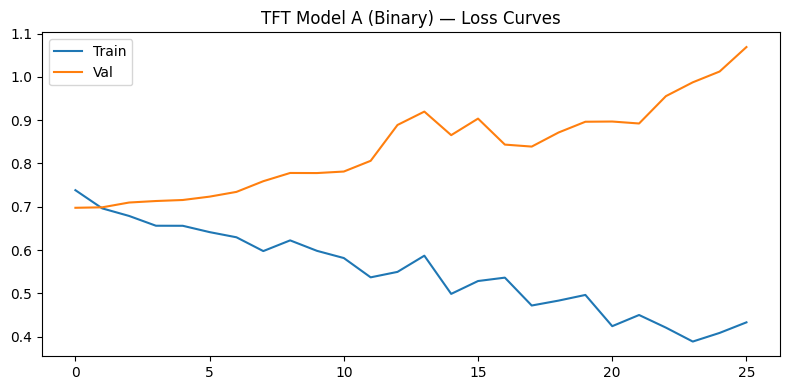

In [ ]:
EPOCHS    = 50
optimizer = torch.optim.Adam(model_a.parameters(), lr=1e-4, weight_decay=1e-3)
criterion = nn.CrossEntropyLoss(weight=weights_bin)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

best_val_loss    = float('inf')
patience_counter = 0
PATIENCE         = 25
train_losses, val_losses = [], []

print('Training TFT Model A (Binary Forecaster)...')
for epoch in range(EPOCHS):
    model_a.train()
    batch_losses = []
    for xb, yb in train_loader_bin:
        optimizer.zero_grad()
        loss = criterion(model_a(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_a.parameters(), 1.0)
        optimizer.step()
        batch_losses.append(loss.item())
    scheduler.step()

    model_a.eval()
    with torch.no_grad():
        val_loss = criterion(model_a(X_test), y_test_bin).item()
    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model_a.state_dict(), 'best_tft_binary.pt')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

    print(f'Epoch {epoch+1:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}')

plt.figure(figsize=(8,4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.title('TFT Model A (Binary) — Loss Curves')
plt.legend(); plt.tight_layout()
plt.savefig('tft_binary_loss.png', dpi=150); plt.show()


#### Evaluate Model A


TFT MODEL A — BINARY FORECASTER RESULTS
Accuracy : 28.21%
F1 Score : 0.4059
RMSE     : 0.8473
MAE      : 0.7179

                  precision    recall  f1-score   support

            Safe       0.98      0.26      0.42       189
Breakdown Coming       0.03      0.83      0.07         6

        accuracy                           0.28       195
       macro avg       0.51      0.55      0.24       195
    weighted avg       0.95      0.28      0.41       195



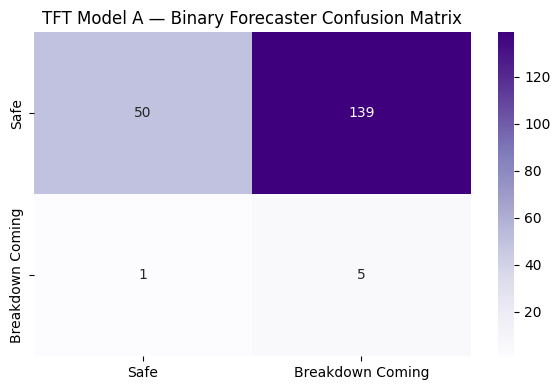

✅ Model A results saved.


In [6]:
model_a.load_state_dict(torch.load('best_tft_binary.pt'))
model_a.eval()
with torch.no_grad():
    y_pred_bin = np.argmax(torch.softmax(model_a(X_test), dim=1).cpu().numpy(), axis=1)
    y_true_bin = y_test_bin.cpu().numpy()

acc  = accuracy_score(y_true_bin, y_pred_bin)
f1   = f1_score(y_true_bin, y_pred_bin, average='weighted')
rmse = np.sqrt(mean_squared_error(y_true_bin, y_pred_bin))
mae  = mean_absolute_error(y_true_bin, y_pred_bin)

print('='*50)
print('TFT MODEL A — BINARY FORECASTER RESULTS')
print('='*50)
print(f'Accuracy : {acc*100:.2f}%')
print(f'F1 Score : {f1:.4f}')
print(f'RMSE     : {rmse:.4f}')
print(f'MAE      : {mae:.4f}')
print()
print(classification_report(y_true_bin, y_pred_bin, target_names=['Safe','Breakdown Coming']))

cm = confusion_matrix(y_true_bin, y_pred_bin)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Safe','Breakdown Coming'],
            yticklabels=['Safe','Breakdown Coming'])
plt.title('TFT Model A — Binary Forecaster Confusion Matrix')
plt.tight_layout()
plt.savefig('tft_binary_confusion.png', dpi=150); plt.show()

tft_binary_results = {'model':'TFT Forecaster','accuracy':acc,'f1':f1,'rmse':rmse,'mae':mae}
with open('tft_binary_results.pkl','wb') as f: pickle.dump(tft_binary_results, f)
print('✅ Model A results saved.')


---
## Model B - Type Forecaster
> Trained only on records where future_breakdown = 1
>
> Predicts which breakdown type is coming


In [7]:
# Filter: only sequences where breakdown IS coming
mask_train = d['y_fc_train_bin_seq'] == 1
mask_test  = d['y_fc_test_bin_seq'] == 1

X_tr_type = torch.FloatTensor(d['X_fc_train_seq'][mask_train]).to(DEVICE)
X_te_type = torch.FloatTensor(d['X_fc_test_seq'][mask_test]).to(DEVICE)
y_tr_type = torch.LongTensor(d['y_fc_train_type_seq'][mask_train]).to(DEVICE)
y_te_type = torch.LongTensor(d['y_fc_test_type_seq'][mask_test]).to(DEVICE)

# Only keep classes that appear in the filtered data
# Re-encode to consecutive integers
from sklearn.preprocessing import LabelEncoder as LE
unique_types_train = np.unique(d['y_fc_train_type_seq'][mask_train])
print(f'✅ Type forecaster data ready.')
print(f'   Train: {X_tr_type.shape}  Test: {X_te_type.shape}')

# Class weights for type
if len(unique_types_train) > 1:
    cc_type = np.bincount(d['y_fc_train_type_seq'][mask_train])
    # Remove zero counts
    cc_type_nonzero = cc_type[cc_type > 0]
    cw_type = 1.0 / cc_type
    cw_type[cc_type == 0] = 0
    cw_type = cw_type / cw_type[cw_type > 0].sum() * (cc_type > 0).sum()
    weights_type = torch.FloatTensor(cw_type).to(DEVICE)
    print(f'   Type class counts : {cc_type}')

train_loader_type = DataLoader(TensorDataset(X_tr_type, y_tr_type), batch_size=32, shuffle=True)


✅ Type forecaster data ready.
   Train: torch.Size([24, 5, 67])  Test: torch.Size([6, 5, 67])
   Type class counts : [ 4  0 20]


TFT Model B (Type) parameters: 115,267
Training TFT Model B (Type Forecaster)...
Epoch   1 | Train: 1.1651 | Val: 1.1638
Epoch   2 | Train: 1.1223 | Val: 1.1505
Epoch   3 | Train: 1.1537 | Val: 1.1380
Epoch   4 | Train: 1.1297 | Val: 1.1263
Epoch   5 | Train: 1.0850 | Val: 1.1162
Epoch   6 | Train: 1.0777 | Val: 1.1069
Epoch   7 | Train: 1.0646 | Val: 1.0965
Epoch   8 | Train: 1.0525 | Val: 1.0863
Epoch   9 | Train: 0.9967 | Val: 1.0761
Epoch  10 | Train: 1.0303 | Val: 1.0665
Epoch  11 | Train: 1.0347 | Val: 1.0572
Epoch  12 | Train: 1.0057 | Val: 1.0481
Epoch  13 | Train: 0.9794 | Val: 1.0396
Epoch  14 | Train: 1.0261 | Val: 1.0319
Epoch  15 | Train: 0.9840 | Val: 1.0245
Epoch  16 | Train: 0.9695 | Val: 1.0175
Epoch  17 | Train: 0.9833 | Val: 1.0112
Epoch  18 | Train: 0.9791 | Val: 1.0056
Epoch  19 | Train: 0.9648 | Val: 1.0003
Epoch  20 | Train: 0.9650 | Val: 0.9952
Epoch  21 | Train: 0.9427 | Val: 0.9907
Epoch  22 | Train: 0.9134 | Val: 0.9865
Epoch  23 | Train: 0.9039 | Val: 0.9824

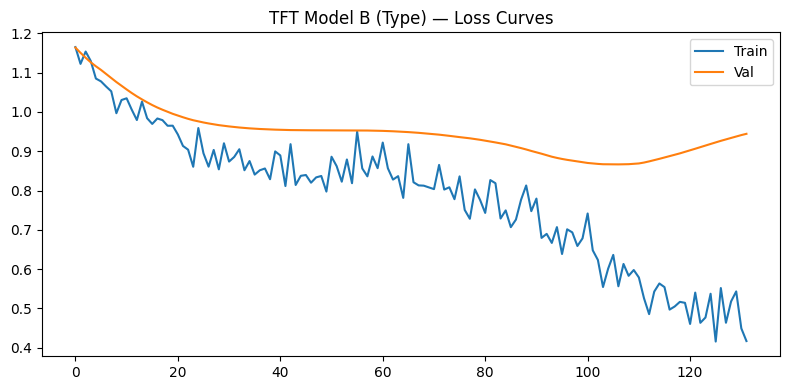

In [8]:
model_b = TFT_Forecaster(
    num_features=NUM_FEATURES, time_steps=TIME_STEPS,
    num_classes=NUM_REASON_CLASSES, hidden_size=64, num_heads=4, dropout=0.3
).to(DEVICE)
print(f'TFT Model B (Type) parameters: {sum(p.numel() for p in model_b.parameters()):,}')

EPOCHS    = 150
optimizer_b = torch.optim.Adam(model_b.parameters(), lr=1e-4, weight_decay=1e-3)
criterion_b = nn.CrossEntropyLoss(weight=weights_type)
scheduler_b = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_b, T_max=50)

best_val_loss_b  = float('inf')
patience_b       = 0
train_losses_b, val_losses_b = [], []

print('Training TFT Model B (Type Forecaster)...')
for epoch in range(EPOCHS):
    model_b.train()
    batch_losses = []
    for xb, yb in train_loader_type:
        optimizer_b.zero_grad()
        loss = criterion_b(model_b(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_b.parameters(), 1.0)
        optimizer_b.step()
        batch_losses.append(loss.item())
    scheduler_b.step()

    model_b.eval()
    with torch.no_grad():
        val_loss = criterion_b(model_b(X_te_type), y_te_type).item()
    train_loss = np.mean(batch_losses)
    train_losses_b.append(train_loss)
    val_losses_b.append(val_loss)

    if val_loss < best_val_loss_b:
        best_val_loss_b = val_loss
        torch.save(model_b.state_dict(), 'best_tft_type.pt')
        patience_b = 0
    else:
        patience_b += 1
        if patience_b >= 25:
            print(f'Early stopping at epoch {epoch+1}')
            break

    print(f'Epoch {epoch+1:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}')

plt.figure(figsize=(8,4))
plt.plot(train_losses_b, label='Train')
plt.plot(val_losses_b, label='Val')
plt.title('TFT Model B (Type) — Loss Curves')
plt.legend(); plt.tight_layout()
plt.savefig('tft_type_loss.png', dpi=150); plt.show()


#### Evaluate Model B


TFT MODEL B — TYPE FORECASTER RESULTS
Accuracy : 83.33%
F1 Score : 0.7576

                       precision    recall  f1-score   support

  High thread tension       0.00      0.00      0.00         1
Sewing without thread       0.83      1.00      0.91         5

             accuracy                           0.83         6
            macro avg       0.42      0.50      0.45         6
         weighted avg       0.69      0.83      0.76         6



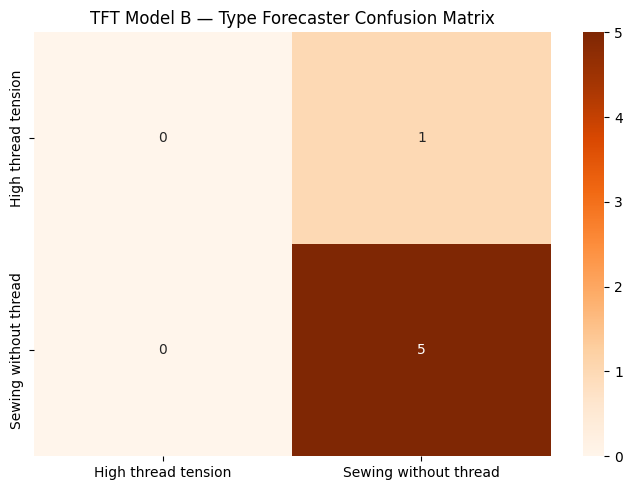

In [9]:
model_b.load_state_dict(torch.load('best_tft_type.pt'))
model_b.eval()
with torch.no_grad():
    y_pred_type = np.argmax(torch.softmax(model_b(X_te_type), dim=1).cpu().numpy(), axis=1)
    y_true_type = y_te_type.cpu().numpy()

# Get only classes that appear in test data (excludes 'No Breakdown')
unique_labels = sorted(set(y_true_type) | set(y_pred_type))
label_names = [encoder_reason.classes_[i] for i in unique_labels]

print('='*50)
print('TFT MODEL B — TYPE FORECASTER RESULTS')
print('='*50)
print(f'Accuracy : {accuracy_score(y_true_type, y_pred_type)*100:.2f}%')
print(f'F1 Score : {f1_score(y_true_type, y_pred_type, average="weighted"):.4f}')
print()
print(classification_report(y_true_type, y_pred_type, labels=unique_labels, target_names=label_names))

cm = confusion_matrix(y_true_type, y_pred_type, labels=unique_labels)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=label_names, yticklabels=label_names)
plt.title('TFT Model B — Type Forecaster Confusion Matrix')
plt.tight_layout()
plt.savefig('tft_type_confusion.png', dpi=150); plt.show()

#### Save Artifacts


In [10]:
tft_forecast_config = {
    'num_features'       : NUM_FEATURES,
    'time_steps'         : TIME_STEPS,
    'H'                  : H,
    'num_classes_binary'  : 2,
    'num_classes_type'    : NUM_REASON_CLASSES,
    'hidden_size'         : 64,
    'num_heads'           : 4,
}
with open('tft_forecast_config.pkl','wb') as f: pickle.dump(tft_forecast_config, f)

print('✅ Saved:')
print('   best_tft_binary.pt        — Binary forecaster weights')
print('   best_tft_type.pt          — Type forecaster weights')
print('   tft_forecast_config.pkl   — Model config')
print('   tft_binary_results.pkl    — Binary evaluation metrics')


✅ Saved:
   best_tft_binary.pt        — Binary forecaster weights
   best_tft_type.pt          — Type forecaster weights
   tft_forecast_config.pkl   — Model config
   tft_binary_results.pkl    — Binary evaluation metrics
